# Scenario B2 Mixed: Multiple Suppliers — With REC (Mixed Prosumers)

**Description:** Two suppliers with a shared cross-supplier REC, using mixed
prosumer profiles. Prosumers are modelled as **full prosumers** — both local
load AND RES generation are billed. REC_01 performs proportional sharing
across all 9 participants before supplier billing.

**Participant–supplier assignment:**
| Supplier / BG | Participants | Type |
|---|---|---|
| SUP_A / BG_A | consumer_001–006 | 6 consumers (pure load) |
| SUP_B / BG_B | prosumer_001–003 | 3 prosumers (RES + load) |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (consumers only), BG_B (prosumers only) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Mixed** (RES + local load both billed) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Settlement basis | Corrected meter readings after REC sharing |
| Battery | None |

**Research role:** Most realistic multi-supplier REC configuration. Prosumer nodes
both consume and generate, reducing net export into the REC while also participating
as consumers in the sharing algorithm.

**Comparison pairs (mixed-prosumer track):**
- B2-mixed vs B1-mixed → incremental REC value under multi-supplier
- B2-mixed vs A2-mixed → single vs multi-supplier with equivalent REC structure
- B2-mixed vs B2-forecasts-mixed → impact of explicit forecast scheduling on imbalance costs

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [11]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [12]:
CONFIG_FILE = "B2_mixed_multiple_suppliers_with_rec(mixed prosumers).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [13]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2_mixed
  System  : Multiple Suppliers with REC - Scenario B2
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (70272, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 27)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [14]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €      154.89
      Retail Sales        : €   23,077.72
      ────────────────────────────────────────────
      Total Revenue       : €   23,232.61

    COSTS:
      Market Purchases    : €    4,749.35
      Balancing Penalties  : €    1,137.92
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    5,887.27

    PROFIT/LOSS:
      Annual Total         : €   17,345.34
      Monthly Average      : €    1,445.44

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :       -33.51 MWh
      BG Actual Position   :       114.81 MWh
      BG Forecast Position :       148.33 MWh

    REC SHARING:
      Shared Energy        :        33.52 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      741.57
      Balancing Rewards   : €    1

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

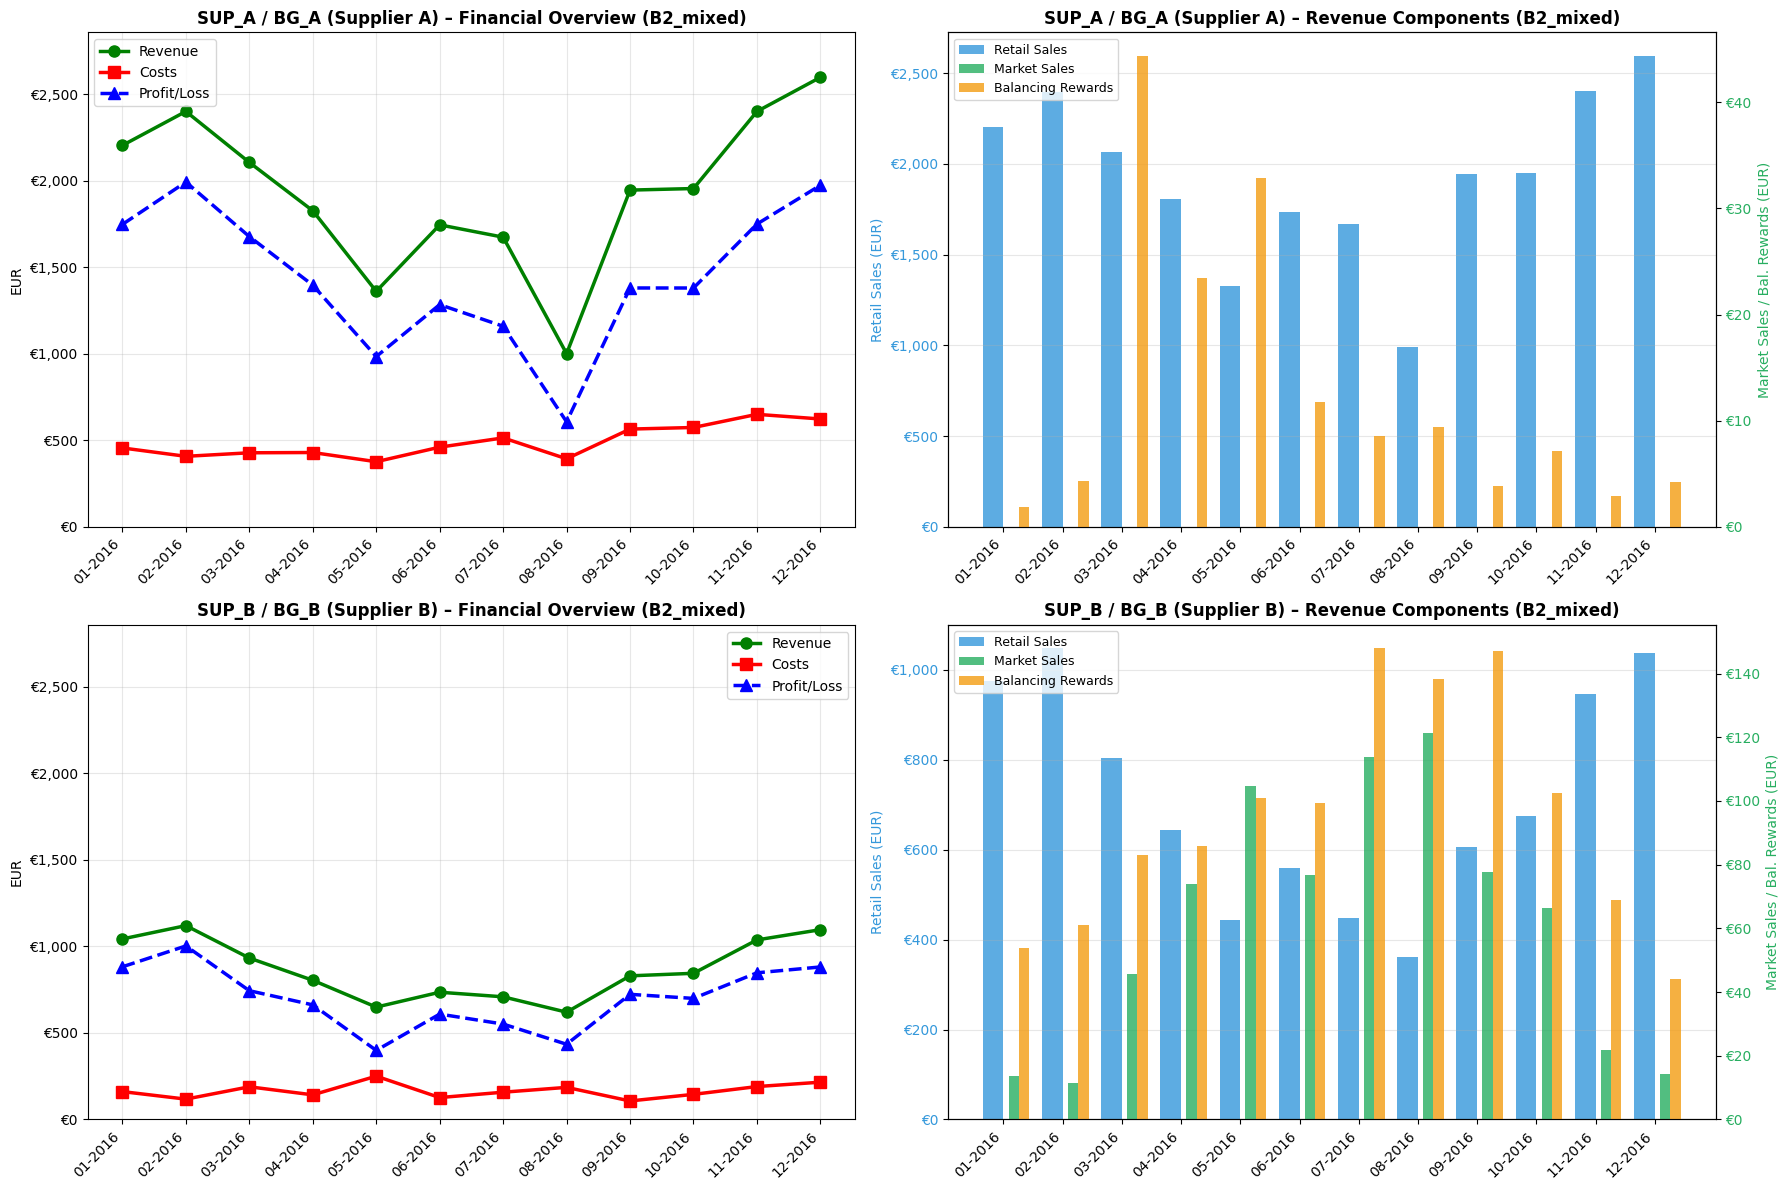

In [15]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

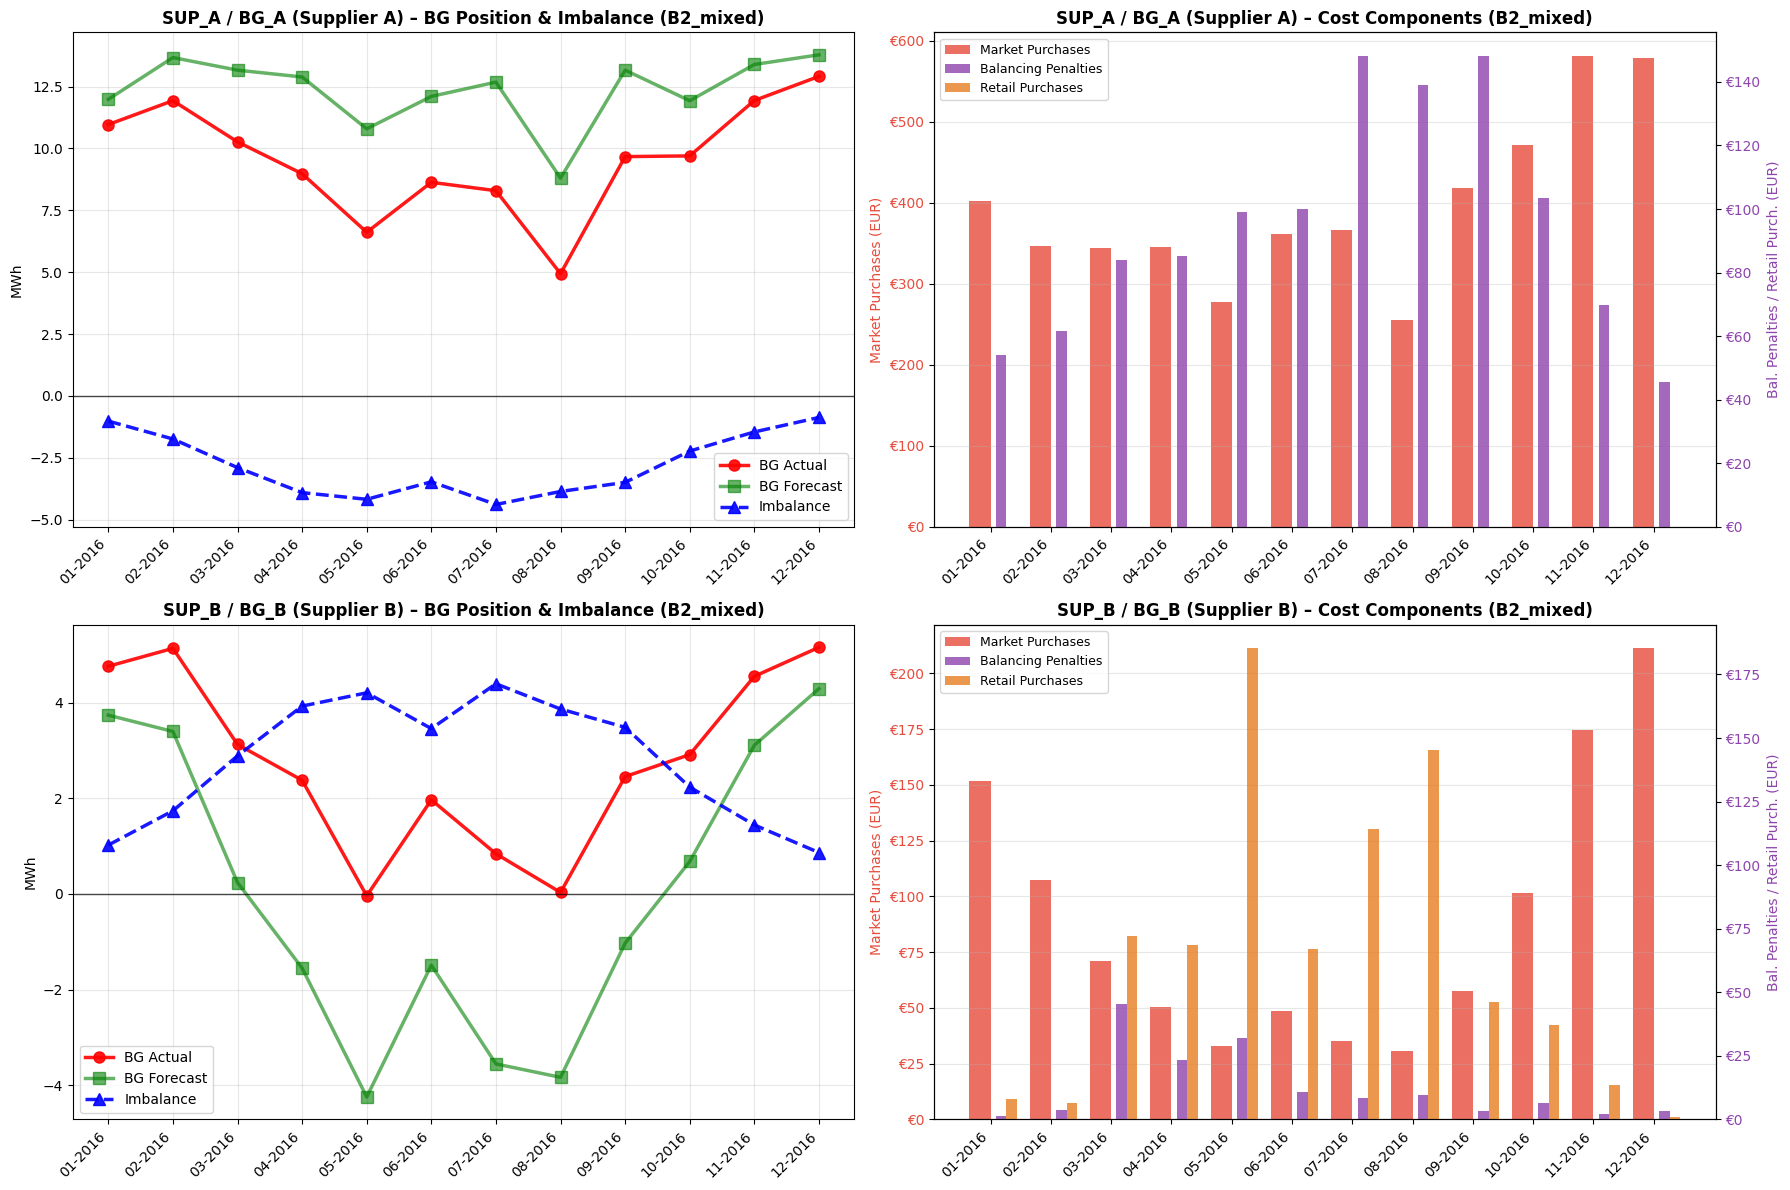

In [16]:
pipe.plot_imbalances()

## 7. REC Analysis & Monthly Data
Display total energy shared within the REC and monthly analysis DataFrame with all financial metrics.

In [17]:
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")
pipe.es_monthly_analysis_df

Total Shared Energy: 94.79 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,13.186590,0.000000,443.195602,0.000000,-1.204923,0.000000,29.579375,...,1.021452,0.000000,1.855860,2203.788001,2205.643861,402.722865,53.952569,0.000000,456.675435,1748.968426
1,01-2016,SUP_B,BG_B,4.740502,0.468620,169.847102,12.558599,-0.498628,0.036027,29.579375,...,2.038264,13.699263,53.729212,976.057358,1043.485833,151.759008,1.260296,8.011995,161.031299,882.454534
2,02-2016,SUP_A,BG_A,15.039090,0.000000,381.248817,0.000000,-1.368652,0.000000,22.463459,...,1.738792,0.000000,4.330261,2397.657024,2401.987285,346.584299,61.713340,0.000000,408.297639,1993.689646
3,02-2016,SUP_B,BG_B,4.483778,0.480382,121.431768,9.391745,-0.524046,0.084000,22.463459,...,3.546330,11.435563,61.197960,1047.790804,1120.424328,107.150376,3.716295,6.597385,117.464056,1002.960272
4,03-2016,SUP_A,BG_A,14.470822,0.000000,378.984251,0.000000,-1.309847,0.000000,24.094009,...,2.897861,0.000000,44.371295,2062.924160,2107.295455,344.632796,84.084713,0.000000,428.717509,1678.577946
5,03-2016,SUP_B,BG_B,2.931786,2.166633,81.353209,41.500099,-0.365589,0.160858,24.094009,...,5.637158,45.633976,82.955550,804.501577,933.091103,71.231445,45.261121,72.301376,188.793943,744.297160
6,04-2016,SUP_A,BG_A,14.175561,0.000000,379.558670,0.000000,-1.289901,0.000000,25.257687,...,3.915622,0.000000,23.488614,1804.414009,1827.902622,344.966322,85.309644,0.000000,430.275967,1397.626656
7,04-2016,SUP_B,BG_B,1.997004,3.056302,58.382940,68.211175,-0.271733,0.219637,25.257687,...,7.241135,73.861086,85.734480,644.850651,804.446217,50.400111,23.206675,68.588396,142.195182,662.251035
8,05-2016,SUP_A,BG_A,11.874686,0.000000,305.977308,0.000000,-1.083823,0.000000,22.993579,...,4.178335,0.000000,32.888613,1329.126110,1362.014723,278.020453,99.082646,0.000000,377.103098,984.911625
9,05-2016,SUP_B,BG_B,1.399468,5.225159,38.423133,98.720847,-0.195751,0.222037,22.993579,...,7.604534,104.641384,100.869608,443.930486,649.441477,32.924145,32.051924,185.257366,250.233435,399.208042


In [21]:
df = pipe.es_monthly_analysis_df
s = df[df['supplier_id'] == 'SUP_A']
print("SUPPLIER A")
print(f"Actual BG: {s['balancing_group_actual_mwh'].sum():.4f}")
print(f"Forecast BG: {s['balancing_group_forecast_mwh'].sum():.4f}")
print(f"Imbalance: {(s['balancing_group_actual_mwh'].sum() - s['balancing_group_forecast_mwh'].sum()):+.4f}")
print(f"Bal reward: {s['imbalance_reward'].sum():.2f}")
print(f"Bal penalty: {s['imbalance_penalty'].sum():.2f}")
print(f"MS: {s['revenue_energy_market_sales_eur'].sum():.2f}")
print(f"BR: {s['revenue_balancing_rewards_eur'].sum():.2f}")
print(f"RS: {s['revenue_retail_sales_eur'].sum():.2f}")
print(f"TotRev: {s['total_revenue_eur'].sum():.2f}")
print(f"MP: {s['cost_energy_market_purchases_eur'].sum():.2f}")
print(f"BP: {s['cost_balancing_penalties_eur'].sum():.2f}")
print(f"FI: {s['cost_retail_purchases_eur'].sum():.2f}")
print(f"TotCost: {s['total_costs_eur'].sum():.2f}")
print(f"P/L: {s['profit_loss_eur'].sum():.2f}")
print(f"avg: {s['profit_loss_eur'].mean():.2f}, min: {s['profit_loss_eur'].min():.2f}, max: {s['profit_loss_eur'].max():.2f}")
print(f"REC shared: {s['internal_shared_energy_mwh'].sum():.4f}")
for _, r in s.iterrows():
    print(f"  {r['datetime']}: bg={r['balancing_group_actual_mwh']:.4f} fc={r['balancing_group_forecast_mwh']:.4f} rec={r['internal_shared_energy_mwh']:.4f} pnl={r['profit_loss_eur']:.2f}")

SUPPLIER A
Actual BG: 114.8145
Forecast BG: 148.3263
Imbalance: -33.5118
Bal reward: 154.89
Bal penalty: 1137.92
MS: 0.00
BR: 154.89
RS: 23077.72
TotRev: 23232.61
MP: 4749.35
BP: 1137.92
FI: 0.00
TotCost: 5887.27
P/L: 17345.34
avg: 1445.44, min: 607.78, max: 1993.69
REC shared: 33.5153
  01-2016: bg=10.9641 fc=11.9817 rec=1.0215 pnl=1748.97
  02-2016: bg=11.9286 fc=13.6704 rec=1.7388 pnl=1993.69
  03-2016: bg=10.2633 fc=13.1610 rec=2.8979 pnl=1678.58
  04-2016: bg=8.9772 fc=12.8857 rec=3.9156 pnl=1397.63
  05-2016: bg=6.6126 fc=10.7909 rec=4.1783 pnl=984.91
  06-2016: bg=8.6294 fc=12.1006 rec=3.4724 pnl=1285.06
  07-2016: bg=8.2910 fc=12.6778 rec=4.3848 pnl=1160.21
  08-2016: bg=4.9379 fc=8.7992 rec=3.8611 pnl=607.78
  09-2016: bg=9.6682 fc=13.1616 rec=3.4947 pnl=1381.44
  10-2016: bg=9.6969 fc=11.9255 rec=2.2272 pnl=1381.24
  11-2016: bg=11.9352 fc=13.3908 rec=1.4515 pnl=1750.82
  12-2016: bg=12.9102 fc=13.7811 rec=0.8716 pnl=1975.02


In [22]:
s = df[df['supplier_id'] == 'SUP_B']
print("SUPPLIER B")
print(f"Actual BG: {s['balancing_group_actual_mwh'].sum():.4f}")
print(f"Forecast BG: {s['balancing_group_forecast_mwh'].sum():.4f}")
print(f"Imbalance: {(s['balancing_group_actual_mwh'].sum() - s['balancing_group_forecast_mwh'].sum()):+.4f}")
print(f"Bal reward: {s['imbalance_reward'].sum():.2f}")
print(f"Bal penalty: {s['imbalance_penalty'].sum():.2f}")
print(f"MS: {s['revenue_energy_market_sales_eur'].sum():.2f}")
print(f"BR: {s['revenue_balancing_rewards_eur'].sum():.2f}")
print(f"RS: {s['revenue_retail_sales_eur'].sum():.2f}")
print(f"TotRev: {s['total_revenue_eur'].sum():.2f}")
print(f"MP: {s['cost_energy_market_purchases_eur'].sum():.2f}")
print(f"BP: {s['cost_balancing_penalties_eur'].sum():.2f}")
print(f"FI: {s['cost_retail_purchases_eur'].sum():.2f}")
print(f"TotCost: {s['total_costs_eur'].sum():.2f}")
print(f"P/L: {s['profit_loss_eur'].sum():.2f}")
print(f"avg: {s['profit_loss_eur'].mean():.2f}, min: {s['profit_loss_eur'].min():.2f}, max: {s['profit_loss_eur'].max():.2f}")
print(f"REC shared: {s['internal_shared_energy_mwh'].sum():.4f}")
for _, r in s.iterrows():
    print(f"  {r['datetime']}: bg={r['balancing_group_actual_mwh']:.4f} fc={r['balancing_group_forecast_mwh']:.4f} rec={r['internal_shared_energy_mwh']:.4f} pnl={r['profit_loss_eur']:.2f}")

SUPPLIER B
Actual BG: 33.2603
Forecast BG: -0.2510
Imbalance: +33.5113
Bal reward: 1132.99
Bal penalty: 149.60
MS: 741.57
BR: 1132.99
RS: 8550.54
TotRev: 10425.10
MP: 1072.47
BP: 149.60
FI: 764.65
TotCost: 1986.72
P/L: 8438.38
avg: 703.20, min: 399.21, max: 1002.96
REC shared: 61.2767
  01-2016: bg=4.7588 fc=3.7372 rec=2.0383 pnl=882.45
  02-2016: bg=5.1328 fc=3.3954 rec=3.5463 pnl=1002.96
  03-2016: bg=3.1251 fc=0.2387 rec=5.6372 pnl=744.30
  04-2016: bg=2.3758 fc=-1.5507 rec=7.2411 pnl=662.25
  05-2016: bg=-0.0397 fc=-4.2435 rec=7.6045 pnl=399.21
  06-2016: bg=1.9671 fc=-1.4890 rec=6.2155 pnl=608.96
  07-2016: bg=0.8398 fc=-3.5527 rec=7.1650 pnl=551.43
  08-2016: bg=0.0320 fc=-3.8329 rec=7.4747 pnl=434.62
  09-2016: bg=2.4528 fc=-1.0297 rec=5.9589 pnl=723.29
  10-2016: bg=2.9123 fc=0.6793 rec=3.9598 pnl=699.72
  11-2016: bg=4.5485 fc=3.1069 rec=2.7739 pnl=847.67
  12-2016: bg=5.1548 fc=4.2898 rec=1.6614 pnl=881.52


In [24]:
# SUP_A costs per month
s = df[df['supplier_id'] == 'SUP_A']
for _, r in s.iterrows():
    print(f"{r['datetime']}: MP={r['cost_energy_market_purchases_eur']:.2f} BP={r['cost_balancing_penalties_eur']:.2f} FI={r['cost_retail_purchases_eur']:.2f} Tot={r['total_costs_eur']:.2f}")

01-2016: MP=402.72 BP=53.95 FI=0.00 Tot=456.68
02-2016: MP=346.58 BP=61.71 FI=0.00 Tot=408.30
03-2016: MP=344.63 BP=84.08 FI=0.00 Tot=428.72
04-2016: MP=344.97 BP=85.31 FI=0.00 Tot=430.28
05-2016: MP=278.02 BP=99.08 FI=0.00 Tot=377.10
06-2016: MP=361.23 BP=100.02 FI=0.00 Tot=461.26
07-2016: MP=366.70 BP=148.17 FI=0.00 Tot=514.87
08-2016: MP=255.23 BP=138.87 FI=0.00 Tot=394.10
09-2016: MP=417.75 BP=148.00 FI=0.00 Tot=565.75
10-2016: MP=471.61 BP=103.38 FI=0.00 Tot=574.99
11-2016: MP=581.22 BP=69.82 FI=0.00 Tot=651.04
12-2016: MP=578.69 BP=45.52 FI=0.00 Tot=624.20


In [25]:
# SUP_B costs & revenue per month
s = df[df['supplier_id'] == 'SUP_B']
print("SUP_B Costs:")
for _, r in s.iterrows():
    print(f"  {r['datetime']}: MP={r['cost_energy_market_purchases_eur']:.2f} BP={r['cost_balancing_penalties_eur']:.2f} FI={r['cost_retail_purchases_eur']:.2f} Tot={r['total_costs_eur']:.2f}")
print("\nSUP_B Revenue:")
for _, r in s.iterrows():
    print(f"  {r['datetime']}: MS={r['revenue_energy_market_sales_eur']:.2f} BR={r['revenue_balancing_rewards_eur']:.2f} RS={r['revenue_retail_sales_eur']:.2f} Tot={r['total_revenue_eur']:.2f}")

SUP_B Costs:
  01-2016: MP=151.76 BP=1.26 FI=8.01 Tot=161.03
  02-2016: MP=107.15 BP=3.72 FI=6.60 Tot=117.46
  03-2016: MP=71.23 BP=45.26 FI=72.30 Tot=188.79
  04-2016: MP=50.40 BP=23.21 FI=68.59 Tot=142.20
  05-2016: MP=32.92 BP=32.05 FI=185.26 Tot=250.23
  06-2016: MP=48.43 BP=10.89 FI=67.15 Tot=126.47
  07-2016: MP=35.09 BP=8.35 FI=114.08 Tot=157.52
  08-2016: MP=30.63 BP=9.72 FI=145.11 Tot=185.46
  09-2016: MP=57.52 BP=3.27 FI=46.09 Tot=106.88
  10-2016: MP=101.69 BP=6.36 FI=37.05 Tot=145.10
  11-2016: MP=174.45 BP=2.29 FI=13.40 Tot=190.13
  12-2016: MP=211.20 BP=3.22 FI=1.02 Tot=215.44

SUP_B Revenue:
  01-2016: MS=13.70 BR=53.73 RS=976.06 Tot=1043.49
  02-2016: MS=11.44 BR=61.20 RS=1047.79 Tot=1120.42
  03-2016: MS=45.63 BR=82.96 RS=804.50 Tot=933.09
  04-2016: MS=73.86 BR=85.73 RS=644.85 Tot=804.45
  05-2016: MS=104.64 BR=100.87 RS=443.93 Tot=649.44
  06-2016: MS=76.79 BR=99.45 RS=559.18 Tot=735.43
  07-2016: MS=113.96 BR=147.91 RS=447.08 Tot=708.94
  08-2016: MS=121.24 BR=138.4

In [26]:
# SUP_A revenue per month
s = df[df['supplier_id'] == 'SUP_A']
for _, r in s.iterrows():
    print(f"{r['datetime']}: MS={r['revenue_energy_market_sales_eur']:.2f} BR={r['revenue_balancing_rewards_eur']:.2f} RS={r['revenue_retail_sales_eur']:.2f} Tot={r['total_revenue_eur']:.2f}")
# Total shared energy
print(f"\nTotal REC shared energy: {df['internal_shared_energy_mwh'].sum():.4f} MWh")

01-2016: MS=0.00 BR=1.86 RS=2203.79 Tot=2205.64
02-2016: MS=0.00 BR=4.33 RS=2397.66 Tot=2401.99
03-2016: MS=0.00 BR=44.37 RS=2062.92 Tot=2107.30
04-2016: MS=0.00 BR=23.49 RS=1804.41 Tot=1827.90
05-2016: MS=0.00 BR=32.89 RS=1329.13 Tot=1362.01
06-2016: MS=0.00 BR=11.81 RS=1734.50 Tot=1746.31
07-2016: MS=0.00 BR=8.59 RS=1666.49 Tot=1675.08
08-2016: MS=0.00 BR=9.37 RS=992.51 Tot=1001.88
09-2016: MS=0.00 BR=3.88 RS=1943.30 Tot=1947.18
10-2016: MS=0.00 BR=7.15 RS=1949.07 Tot=1956.23
11-2016: MS=0.00 BR=2.88 RS=2398.98 Tot=2401.86
12-2016: MS=0.00 BR=4.27 RS=2594.95 Tot=2599.22

Total REC shared energy: 94.7920 MWh
